# Final Showdown — 18 Methods × 3 Fraud Datasets

| Section | Methods | Node selector | Feature selector |
|---------|---------|---------------|------------------|
| **S0** Baselines | Random, Degree, Greedy-Raw, PageRank, K-Means | varies | ALL / none |
| **SA** AISO node sampler | Greedy-Dom, AISO-node(Rand/Smart M) | AISO | domain feats |
| **SB** Feat→SGD | MI, mRMR, AISO(Rand/Smart)→SGD | SGD | MI/mRMR/AISO |
| **SC** Feat→AISO | MI/mRMR/AISO(Rand/Smart)→AISO | AISO | MI/mRMR/AISO |

**Datasets**: YelpChi (32 feats, ~45k nodes) · Amazon (25 feats, ~12k nodes) · Elliptic Bitcoin (166 feats, ~47k nodes)

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.sparse import issparse, csr_matrix, diags as sp_diags
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib.patches import Patch
import copy, time
import matplotlib.pyplot as plt
from pathlib import Path

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE         = Path(r'C:\Users\kevin\OneDrive\Desktop\AISO')
GAMMA        = 0.5
GNN_SEED     = 42
SEEDS        = [0, 7, 42, 77, 123]
GNN_BUDGET   = 3
TEST_RATIO   = 0.2
GNN_EPOCHS   = 150
GNN_PATIENCE = 15

DATASET_CONFIGS = {
    'YelpChi': dict(
        mat_path      = BASE / 'YelpChi' / 'YelpChi.mat',
        feat_key      = 'features',
        label_key     = 'label',
        adj_key       = 'homo',
        K_SELECT      = 8,
        N_TYPES       = 6,
        K_DOM         = 5,
        N_DOM_TYPES   = 4,
        N_ILLICIT     = 500,
        N_LICIT       = 5000,
        N_COMBO_TYPES = 3,
    ),
    'Amazon': dict(
        mat_path      = BASE / 'Amazon' / 'Amazon.mat',
        feat_key      = 'features',
        label_key     = 'label',
        adj_key       = 'homo',
        K_SELECT      = 6,
        N_TYPES       = 5,
        K_DOM         = 5,
        N_DOM_TYPES   = 4,
        N_ILLICIT     = 200,
        N_LICIT       = 2000,
        N_COMBO_TYPES = 3,
    ),
    'Elliptic': dict(
        K_SELECT      = 20,
        N_TYPES       = 12,
        K_DOM         = 8,
        N_DOM_TYPES   = 4,
        N_ILLICIT     = 1000,
        N_LICIT       = 10000,
        N_COMBO_TYPES = 3,
    ),
}
print('Device:', DEVICE)

c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
def load_dataset(cfg, seed=GNN_SEED):
    mat = sio.loadmat(str(cfg['mat_path']))
    X = mat[cfg['feat_key']]
    if issparse(X): X = X.toarray()
    X = X.astype(float)
    y = mat[cfg['label_key']].squeeze().astype(int)

    adj = mat[cfg['adj_key']]
    if issparse(adj):
        coo = adj.tocoo()
    else:
        coo = csr_matrix(adj).tocoo()
    src = coo.row.astype(np.int64)
    dst = coo.col.astype(np.int64)
    src_bi = np.concatenate([src, dst])
    dst_bi = np.concatenate([dst, src])
    mask   = src_bi != dst_bi
    src_bi, dst_bi = src_bi[mask], dst_bi[mask]
    edge_index = torch.tensor(np.stack([src_bi, dst_bi]), dtype=torch.long)
    ei_np = edge_index.numpy()

    N = len(y)
    idx = np.arange(N)
    tr_idx, te_idx = train_test_split(idx, test_size=TEST_RATIO, stratify=y, random_state=seed)
    train_mask = np.zeros(N, dtype=bool); test_mask = np.zeros(N, dtype=bool)
    train_mask[tr_idx] = True; test_mask[te_idx] = True

    X_scaled          = StandardScaler().fit_transform(X)
    train_illicit_idx = np.where(train_mask & (y == 1))[0]
    train_licit_idx   = np.where(train_mask & (y == 0))[0]

    n_licit   = min(cfg['N_LICIT'],   len(train_licit_idx))
    n_illicit = min(cfg['N_ILLICIT'], len(train_illicit_idx))
    sel_n     = np.random.RandomState(GNN_SEED).choice(train_licit_idx, n_licit, replace=False)

    illicit_ratio = (y == 1).sum() / N
    print('  %s: N=%d  illicit=%.1f%%  D=%d  train_illicit=%d' % (
        cfg['mat_path'].parent.name, N, 100*illicit_ratio, X.shape[1], len(train_illicit_idx)))

    return dict(
        X_raw=X, X_scaled=X_scaled, y=y,
        edge_index=edge_index, ei_np=ei_np,
        train_mask=train_mask, test_mask=test_mask,
        train_illicit_idx=train_illicit_idx, train_licit_idx=train_licit_idx,
        sel_n=sel_n,
        X_illicit_pool=X_scaled[train_illicit_idx],
        X_tr_all=X_scaled[train_mask],
        y_tr_all=y[train_mask],
        N_NODES=N, D=X.shape[1],
        N_ILLICIT=n_illicit, N_LICIT=n_licit,
    )


def load_elliptic(cfg):
    ELLIPTIC_DIR = BASE / 'Elliptic Bitcoin' / 'elliptic_bitcoin_dataset'
    feat_df = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_features.csv'), header=None)
    cls_df  = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_classes.csv'))
    edge_df = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_edgelist.csv'))

    feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, 167)]
    df      = feat_df.merge(cls_df, on='txId')
    labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)

    X      = labeled[[f'f{i}' for i in range(1, 167)]].values.astype(float)
    y      = (labeled['class'] == '1').astype(int).values
    ts_all = labeled['f1'].astype(int).values

    txid_to_idx = {txid: i for i, txid in enumerate(labeled['txId'].values)}
    s_arr = edge_df.iloc[:, 0].values
    d_arr = edge_df.iloc[:, 1].values
    s_map = np.array([txid_to_idx.get(t, -1) for t in s_arr])
    d_map = np.array([txid_to_idx.get(t, -1) for t in d_arr])
    ok    = (s_map >= 0) & (d_map >= 0) & (s_map != d_map)
    src, dst = s_map[ok], d_map[ok]
    src_bi = np.concatenate([src, dst])
    dst_bi = np.concatenate([dst, src])
    edge_index = torch.tensor(np.stack([src_bi, dst_bi]), dtype=torch.long)
    ei_np = edge_index.numpy()

    N          = len(y)
    train_mask = ts_all <= 34
    test_mask  = ts_all > 34

    X_scaled          = StandardScaler().fit_transform(X)
    train_illicit_idx = np.where(train_mask & (y == 1))[0]
    train_licit_idx   = np.where(train_mask & (y == 0))[0]

    n_illicit = min(cfg['N_ILLICIT'], len(train_illicit_idx))
    n_licit   = min(cfg['N_LICIT'],   len(train_licit_idx))
    sel_n     = np.random.RandomState(GNN_SEED).choice(train_licit_idx, n_licit, replace=False)

    illicit_ratio = (y == 1).sum() / N
    print('  Elliptic: N=%d  illicit=%.1f%%  D=%d  train_illicit=%d' % (
        N, 100*illicit_ratio, X.shape[1], len(train_illicit_idx)))

    return dict(
        X_raw=X, X_scaled=X_scaled, y=y,
        edge_index=edge_index, ei_np=ei_np,
        train_mask=train_mask, test_mask=test_mask,
        train_illicit_idx=train_illicit_idx, train_licit_idx=train_licit_idx,
        sel_n=sel_n,
        X_illicit_pool=X_scaled[train_illicit_idx],
        X_tr_all=X_scaled[train_mask],
        y_tr_all=y[train_mask],
        N_NODES=N, D=X.shape[1],
        N_ILLICIT=n_illicit, N_LICIT=n_licit,
    )


print('=== YelpChi ===')
yelp_data = load_dataset(DATASET_CONFIGS['YelpChi'])
print('=== Amazon ===')
amzn_data = load_dataset(DATASET_CONFIGS['Amazon'])
print('=== Elliptic ===')
elliptic_data = load_elliptic(DATASET_CONFIGS['Elliptic'])

=== YelpChi ===
  YelpChi: N=45954  illicit=14.5%  D=32  train_illicit=5342
=== Amazon ===
  Amazon: N=11944  illicit=6.9%  D=25  train_illicit=657
=== Elliptic ===
  Elliptic: N=46564  illicit=9.8%  D=166  train_illicit=3462


In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


def make_evaluate_gnn(data, gnn_seed=GNN_SEED):
    X_scaled          = data['X_scaled']
    y_all             = data['y']
    train_illicit_idx = data['train_illicit_idx']
    sel_n             = data['sel_n']
    ei_np             = data['ei_np']
    N_NODES           = data['N_NODES']
    test_mask         = data['test_mask']
    _LU               = np.full(N_NODES, -1, dtype=np.int32)

    def evaluate_gnn(top_n_illicit_local, label=''):
        uniq            = np.unique(top_n_illicit_local)
        sel_anom_global = train_illicit_idx[uniq]
        test_global     = np.where(test_mask)[0]
        sub_nodes       = np.unique(np.concatenate([sel_n, sel_anom_global, test_global]))
        n_sub           = len(sub_nodes)

        _LU[:] = -1
        _LU[sub_nodes] = np.arange(n_sub)
        sl = _LU[ei_np[0]]; dl = _LU[ei_np[1]]
        ok = (sl >= 0) & (dl >= 0)
        sub_ei = torch.tensor([sl[ok], dl[ok]], dtype=torch.long).to(DEVICE)
        sub_X  = torch.from_numpy(X_scaled[sub_nodes]).float().to(DEVICE)
        sub_y  = torch.from_numpy(y_all[sub_nodes]).long().to(DEVICE)

        train_set = set(np.concatenate([sel_n, sel_anom_global]).tolist())
        test_set  = set(test_global.tolist())
        tr_gnn = torch.tensor([g in train_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
        te_gnn = torch.tensor([g in test_set  for g in sub_nodes], dtype=torch.bool).to(DEVICE)

        y_tr_sub = y_all[sub_nodes][tr_gnn.cpu().numpy()]
        n0 = int((y_tr_sub == 0).sum()); n1 = int((y_tr_sub == 1).sum())
        cw = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float).to(DEVICE)

        torch.manual_seed(gnn_seed)
        model = GCN(X_scaled.shape[1]).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

        best_loss, best_state, patience = float('inf'), None, 0
        for _ in range(GNN_EPOCHS):
            model.train(); opt.zero_grad()
            loss = F.cross_entropy(model(sub_X, sub_ei)[tr_gnn], sub_y[tr_gnn], weight=cw)
            loss.backward(); opt.step()
            if loss.item() < best_loss:
                best_loss = loss.item(); best_state = copy.deepcopy(model.state_dict()); patience = 0
            else:
                patience += 1
            if patience >= GNN_PATIENCE: break

        model.load_state_dict(best_state); model.eval()
        with torch.no_grad():
            prob = F.softmax(model(sub_X, sub_ei), dim=1)[:, 1].cpu().numpy()

        te_cpu  = te_gnn.cpu().numpy()
        y_te    = y_all[sub_nodes][te_cpu]
        prob_te = prob[te_cpu]
        res = {
            'PR-AUC': average_precision_score(y_te, prob_te),
            'F1':     f1_score(y_te, (prob_te >= 0.5).astype(int), zero_division=0),
            'AUC':    roc_auc_score(y_te, prob_te),
        }
        if label:
            print('  %-44s PR-AUC=%.4f  F1=%.4f' % (label, res['PR-AUC'], res['F1']))
        return res

    return evaluate_gnn

print('GCN factory ready')

GCN factory ready


In [4]:
# ── build_feat_M ─────────────────────────────────────────────
def build_feat_M(X_tr, y_tr, N_TYPES, gamma=GAMMA):
    D = X_tr.shape[1]
    C_abs = np.abs(np.corrcoef(X_tr.T)); np.fill_diagonal(C_abs, 0.0)
    dist  = np.clip(1.0 - C_abs, 0.0, None); np.fill_diagonal(dist, 0.0)
    cl    = AgglomerativeClustering(n_clusters=N_TYPES,
                                     metric='precomputed',
                                     linkage='average').fit_predict(dist)
    MI      = mutual_info_classif(X_tr, y_tr, random_state=42)
    mean_MI = np.array([MI[cl==k].mean() if (cl==k).any() else 0.0 for k in range(N_TYPES)])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)

    def _M(mode):
        M = np.zeros((N_TYPES, N_TYPES))
        for i in range(N_TYPES):
            for j in range(N_TYPES):
                if i == j:
                    M[i][j] = -1.0
                else:
                    fi = np.where(cl==i)[0]; fj = np.where(cl==j)[0]
                    cp = -np.mean(C_abs[np.ix_(fi, fj)])
                    M[i][j] = cp + (gamma * (MI_norm[j] - MI_norm[i]) if mode == 'smart' else 0)
        return M

    return _M('smart'), _M('corr'), cl, MI


# ── mi_selection / mrmr_selection ────────────────────────────
def mi_selection(X_tr, y_tr, X_pool, K, n_illicit, seed):
    mi   = mutual_info_classif(X_tr, y_tr, random_state=seed)
    feat = np.argsort(mi)[::-1][:K]
    sgd  = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                          class_weight='balanced', random_state=seed)
    sgd.fit(X_tr[:, feat], y_tr)
    return feat, np.argsort(sgd.predict_proba(X_pool[:, feat])[:, 1])[-n_illicit:]


def mrmr_selection(X_tr, y_tr, X_pool, K, n_illicit, seed):
    mi    = mutual_info_classif(X_tr, y_tr, random_state=seed)
    Cm    = np.abs(np.corrcoef(X_tr.T)); np.fill_diagonal(Cm, 0.0)
    sel   = [int(np.argmax(mi))]
    rem   = list(range(X_tr.shape[1])); rem.remove(sel[0])
    while len(sel) < K:
        sc   = [mi[f] - float(np.mean(Cm[f, sel])) for f in rem]
        best = rem[int(np.argmax(sc))]
        sel.append(best); rem.remove(best)
    feat = np.array(sel)
    sgd  = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                          class_weight='balanced', random_state=seed)
    sgd.fit(X_tr[:, feat], y_tr)
    return feat, np.argsort(sgd.predict_proba(X_pool[:, feat])[:, 1])[-n_illicit:]


# ── compute_domain_features ──────────────────────────────────
def compute_domain_features(data, cfg):
    N          = data['N_NODES']
    ei         = data['ei_np']
    y          = data['y']
    train_mask = data['train_mask']
    X_scaled   = data['X_scaled']

    vals = np.ones(ei.shape[1], dtype=np.float32)
    adj  = csr_matrix((vals, (ei[0], ei[1])), shape=(N, N))

    deg        = np.array(adj.sum(axis=1), dtype=float).flatten()
    y_tr_only  = (y * train_mask).astype(float)
    tr_float   = train_mask.astype(float)
    neigh_fr   = np.array(adj @ y_tr_only).flatten() / np.maximum(np.array(adj @ tr_float).flatten(), 1)

    deg_safe   = np.maximum(deg, 1)
    adj_norm   = sp_diags(1.0 / deg_safe) @ adj
    neigh_mean = np.array(adj_norm @ X_scaled, dtype=float)

    mi      = mutual_info_classif(neigh_mean[train_mask], y[train_mask], random_state=42)
    top_idx = np.argsort(mi)[::-1][:8]

    dom = np.column_stack([deg, neigh_fr, neigh_mean[:, top_idx]])
    dom = StandardScaler().fit_transform(dom)
    print('  domain features: %d cols' % dom.shape[1])
    return dom


def greedy_dom_selection(X_tr_dom, y_tr, X_pool_dom, n_illicit, seed):
    sgd = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                         class_weight='balanced', random_state=seed)
    sgd.fit(X_tr_dom, y_tr)
    return np.argsort(sgd.predict_proba(X_pool_dom)[:, 1])[-n_illicit:]


# ── AISOwrapperGNN ────────────────────────────────────────────
class AISOwrapperGNN:
    def __init__(self, n_agents=20, n_iter=60, beta=0.15,
                 subsample_ratio=0.15, val_ratio=0.2,
                 T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET):
        self.n_agents = n_agents; self.n_iter = n_iter; self.beta = beta
        self.subsample_ratio = subsample_ratio; self.val_ratio = val_ratio
        self.T_start = T_start; self.T_end = T_end
        self.gnn_budget = gnn_budget

    def select(self, X_tr, y_tr, X_pool, cluster_labels, K_select, n_illicit, M,
               seed=42, method_name=''):
        rng = np.random.RandomState(seed)
        N, D = X_tr.shape; K = M.shape[0]; nb = min(3, self.n_agents - 1)
        n_pool = len(X_pool)

        val_n   = int(self.val_ratio * N)
        val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool); tr_mask[val_idx] = False
        X_val, y_val = X_tr[val_idx], y_tr[val_idx]
        X_t,   y_t   = X_tr[tr_mask], y_tr[tr_mask]
        sub_n = max(50, int(self.subsample_ratio * len(X_t)))

        cache = {}; n_calls = [0]

        def get_mask(Wi, t, explore=True):
            if explore:
                ratio  = t / max(1, self.n_iter - 1)
                T      = self.T_start * ((self.T_end / self.T_start) ** ratio)
                logits = Wi[cluster_labels] / T; logits -= logits.max()
                probs  = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D, K_select, replace=False, p=probs))
            else:
                return tuple(np.argsort(Wi[cluster_labels])[-K_select:])

        def get_score(mask_key, X_sub, y_sub):
            n_calls[0] += 1
            if mask_key not in cache:
                feat = list(mask_key)
                sgd  = SGDClassifier(loss='log_loss', max_iter=5, tol=None,
                                      class_weight='balanced', random_state=seed)
                try:
                    sgd.fit(X_sub[:, feat], y_sub)
                    proxy_auc = roc_auc_score(y_val, sgd.predict_proba(X_val[:, feat])[:, 1])
                    illicit_p = sgd.predict_proba(X_pool[:, feat])[:, 1]
                except Exception:
                    proxy_auc = 0.5; illicit_p = rng.rand(n_pool)
                cache[mask_key] = {'proxy_auc': proxy_auc, 'illicit_scores': illicit_p}
            return cache[mask_key]['proxy_auc']

        def top_n(mask_key):
            return np.argsort(cache[mask_key]['illicit_scores'])[-n_illicit:]

        W = rng.dirichlet(np.ones(K), self.n_agents)
        scores = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            mk  = get_mask(W[i], 0)
            scores[i] = get_score(mk, X_t[sub], y_t[sub])

        for t in range(self.n_iter):
            Cm = W @ M @ W.T; np.fill_diagonal(Cm, 0.0)
            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]
            for i in range(self.n_agents):
                att   = np.argsort(Cm[i])[-nb:]
                att_s = np.array([get_score(get_mask(W[j], t), X_sub, y_sub) for j in att])
                max_s = att_s.max() + 1e-8
                bj    = att[np.argmax(Cm[i, att] * att_s / max_s)]
                W_new = (1 - self.beta) * W[i] + self.beta * W[bj]
                W[i]  = W_new / W_new.sum()
                scores[i] = get_score(get_mask(W[i], t), X_sub, y_sub)

        final_lr = LogisticRegression(solver='liblinear', C=1.0, max_iter=500,
                                       class_weight='balanced', random_state=seed)
        fseen, final_scores = {}, []
        for i in range(self.n_agents):
            mk = get_mask(W[i], self.n_iter, explore=False); feat = list(mk)
            if mk not in fseen:
                try:
                    final_lr.fit(X_t[:, feat], y_t)
                    fseen[mk] = roc_auc_score(y_val, final_lr.predict_proba(X_val[:, feat])[:, 1])
                except Exception:
                    fseen[mk] = 0.5
                if mk not in cache:
                    get_score(mk, X_t, y_t)
            final_scores.append(fseen[mk])

        seen_keys, fidelity_cands = set(), []
        for ai in np.argsort(final_scores)[::-1]:
            mk = get_mask(W[ai], self.n_iter, explore=False)
            if mk not in seen_keys and mk in cache:
                seen_keys.add(mk)
                fidelity_cands.append({'feat_mask': np.array(sorted(mk)),
                                        'top_n_local': top_n(mk),
                                        'proxy_auc': cache[mk]['proxy_auc']})
            if len(fidelity_cands) >= self.gnn_budget: break

        best_mk   = get_mask(W[np.argmax(final_scores)], self.n_iter, explore=False)
        best_feat = np.array(sorted(best_mk))
        sgd_fin   = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                                   class_weight='balanced', random_state=seed)
        try:
            sgd_fin.fit(X_t[:, list(best_mk)], y_t)
            top_n_best = np.argsort(sgd_fin.predict_proba(X_pool[:, list(best_mk)])[:, 1])[-n_illicit:]
        except Exception:
            top_n_best = top_n(best_mk)

        timing = {'cache_size': len(cache), 'best_proxy_auc': max(final_scores)}
        return best_feat, top_n_best, timing, fidelity_cands


print('Core infrastructure ready')

Core infrastructure ready


In [5]:
def degree_selector(data, n_illicit, seed):
    ei  = data['ei_np']
    N   = data['N_NODES']
    tii = data['train_illicit_idx']
    deg = np.bincount(ei[0], minlength=N)
    return np.argsort(deg[tii])[-n_illicit:]


def greedy_raw_selector(data, n_illicit, seed):
    X_pool = data['X_illicit_pool']
    X_tr   = data['X_tr_all']
    y_tr   = data['y_tr_all']
    sgd = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                         class_weight='balanced', random_state=seed)
    sgd.fit(X_tr, y_tr)
    return np.argsort(sgd.predict_proba(X_pool)[:, 1])[-n_illicit:]


def pagerank_selector(data, n_illicit, seed, n_iter=20, alpha=0.85):
    N          = data['N_NODES']
    ei         = data['ei_np']
    y          = data['y']
    train_mask = data['train_mask']
    tii        = data['train_illicit_idx']

    deg    = np.maximum(np.bincount(ei[0], minlength=N), 1).astype(float)
    scores = (y * train_mask).astype(float)
    s_sum  = scores.sum()
    if s_sum > 0: scores /= s_sum

    for _ in range(n_iter):
        new_s = np.zeros(N, dtype=float)
        np.add.at(new_s, ei[0], scores[ei[1]] / deg[ei[1]])
        scores = (1 - alpha) * scores + alpha * new_s

    return np.argsort(scores[tii])[-n_illicit:]


def kmeans_selector(data, n_illicit, seed, n_clusters=6):
    X_pool = data['X_illicit_pool']
    nc     = min(n_clusters, len(X_pool))
    km     = KMeans(n_clusters=nc, random_state=seed, n_init=10)
    labels = km.fit_predict(X_pool)
    rng    = np.random.RandomState(seed)
    sel    = []
    n_per  = max(1, n_illicit // nc)
    for c in range(nc):
        members = np.where(labels == c)[0]
        if len(members) == 0: continue
        sel.extend(rng.choice(members, min(n_per, len(members)), replace=False).tolist())
    sel = list(set(sel))
    if len(sel) < n_illicit:
        rem   = [i for i in range(len(X_pool)) if i not in set(sel)]
        extra = rng.choice(rem, min(n_illicit - len(sel), len(rem)), replace=False)
        sel.extend(extra.tolist())
    return np.array(sel[:n_illicit])


print('Baseline selectors ready')

Baseline selectors ready


In [6]:
def run_combo_aiso_node(feat_indices, X_tr, y_tr, X_pool, N_ILLICIT,
                        N_COMBO_TYPES, seed, M_mode_2='smart'):
    """Stage 2: AISO node sampler on pre-selected feature subspace."""
    X_tr_2   = X_tr[:, feat_indices]
    X_pool_2 = X_pool[:, feat_indices]
    K2       = len(feat_indices)

    nc = min(N_COMBO_TYPES, K2)
    M_smart_2, _, cl_2, _ = build_feat_M(X_tr_2, y_tr, nc)

    if M_mode_2 == 'random':
        M_use_2 = np.random.RandomState(seed).uniform(-0.5, 2.0, (nc, nc))
    else:
        M_use_2 = M_smart_2

    K_select_2 = max(2, K2 // 2)
    wrapper_2  = AISOwrapperGNN(n_agents=20, n_iter=60, beta=0.15,
                                T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET)
    _, top_n_best, _, fid_cands = wrapper_2.select(
        X_tr_2, y_tr, X_pool_2, cl_2, K_select_2, N_ILLICIT, M_use_2, seed=seed)
    return fid_cands[0]['top_n_local'] if fid_cands else top_n_best


print('Combo helpers ready')

Combo helpers ready


In [7]:
def run_all_methods(dataset_name, data, cfg):
    N_ILLICIT     = data['N_ILLICIT']
    K_SELECT      = cfg['K_SELECT']
    N_TYPES       = cfg['N_TYPES']
    K_DOM         = cfg['K_DOM']
    N_DOM_TYPES   = cfg['N_DOM_TYPES']
    N_COMBO_TYPES = cfg['N_COMBO_TYPES']
    X_pool        = data['X_illicit_pool']
    X_tr          = data['X_tr_all']
    y_tr          = data['y_tr_all']
    evaluate_gnn  = make_evaluate_gnn(data)
    all_results   = {}

    def run_seeds(name, fn):
        rl = []
        for seed in SEEDS:
            top_n = fn(seed)
            r = evaluate_gnn(top_n, label='%-26s seed=%d' % (name, seed))
            r['seed'] = seed; rl.append(r)
        all_results[name] = rl

    print('\n' + '='*65)
    print('  ' + dataset_name)
    print('='*65)

    # ── S0: Baselines ──────────────────────────────────────────
    print('\n[S0: Baselines]')
    run_seeds('Random',     lambda s: np.random.RandomState(s).choice(len(X_pool), N_ILLICIT, replace=False))
    run_seeds('Degree',     lambda s: degree_selector(data, N_ILLICIT, s))
    run_seeds('Greedy-Raw', lambda s: greedy_raw_selector(data, N_ILLICIT, s))
    run_seeds('PageRank',   lambda s: pagerank_selector(data, N_ILLICIT, s))
    run_seeds('K-Means',    lambda s: kmeans_selector(data, N_ILLICIT, s))

    # ── SA: Domain features + AISO node sampler ───────────────
    print('\n[SA: Domain feats + AISO node sampler]')
    dom_all  = compute_domain_features(data, cfg)
    dom_pool = dom_all[data['train_illicit_idx']]
    dom_tr   = dom_all[data['train_mask']]

    run_seeds('Greedy-Dom', lambda s: greedy_dom_selection(dom_tr, y_tr, dom_pool, N_ILLICIT, s))

    M_smart_dom, _, dom_cl, _ = build_feat_M(dom_tr, y_tr, N_DOM_TYPES)
    dom_wrapper = AISOwrapperGNN(n_agents=20, n_iter=60, beta=0.15,
                                  T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET)

    for mname, M_cfg in [('AISO-node(Rand M)', 'random'), ('AISO-node(Smart M)', M_smart_dom)]:
        print('  ' + mname)
        rl = []
        for seed in SEEDS:
            M_use = (np.random.RandomState(seed).uniform(-0.5, 2.0, (N_DOM_TYPES, N_DOM_TYPES))
                     if isinstance(M_cfg, str) else M_cfg)
            print('    seed=%d ...' % seed, end='', flush=True)
            t0 = time.time()
            _, top_n_best, timing, fid_cands = dom_wrapper.select(
                dom_tr, y_tr, dom_pool, dom_cl, K_DOM, N_ILLICIT, M_use, seed=seed)
            top_n = fid_cands[0]['top_n_local'] if fid_cands else top_n_best
            print(' %.0fs' % (time.time()-t0), end='')
            r = evaluate_gnn(top_n, label='%-26s seed=%d' % (mname, seed))
            r['seed'] = seed; rl.append(r)
        all_results[mname] = rl

    # ── SB: Feature selection → SGD ───────────────────────────
    print('\n[SB: Feature selection -> SGD]')
    M_smart_b, _, cl_b, _ = build_feat_M(X_tr, y_tr, N_TYPES)
    wrapper_b = AISOwrapperGNN(n_agents=20, n_iter=60, beta=0.15,
                                T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET)

    run_seeds('MI->SGD',   lambda s: mi_selection(X_tr, y_tr, X_pool, K_SELECT, N_ILLICIT, s)[1])
    run_seeds('mRMR->SGD', lambda s: mrmr_selection(X_tr, y_tr, X_pool, K_SELECT, N_ILLICIT, s)[1])

    for mname, M_cfg in [('AISO(Rand)->SGD', 'random'), ('AISO(Smart)->SGD', M_smart_b)]:
        print('  ' + mname)
        rl = []
        for seed in SEEDS:
            M_use = (np.random.RandomState(seed).uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
                     if isinstance(M_cfg, str) else M_cfg)
            print('    seed=%d ...' % seed, end='', flush=True)
            t0 = time.time()
            _, top_n_best, timing, fid_cands = wrapper_b.select(
                X_tr, y_tr, X_pool, cl_b, K_SELECT, N_ILLICIT, M_use, seed=seed)
            top_n = fid_cands[0]['top_n_local'] if fid_cands else top_n_best
            print(' %.0fs' % (time.time()-t0), end='')
            r = evaluate_gnn(top_n, label='%-26s seed=%d' % (mname, seed))
            r['seed'] = seed; rl.append(r)
        all_results[mname] = rl

    # ── SC: Feature selection → AISO node sampler ─────────────
    print('\n[SC: Feature selection -> AISO node sampler]')

    sc_configs = [
        ('MI->AISO(Rand)',     'mi',        'random'),
        ('MI->AISO(Smart)',    'mi',        'smart'),
        ('mRMR->AISO(Rand)',   'mrmr',      'random'),
        ('mRMR->AISO(Smart)',  'mrmr',      'smart'),
        ('AISO(Rand)->AISO',   'aiso_rand', 'smart'),
        ('AISO(Smart)->AISO',  'aiso_smart', 'smart'),
    ]

    for mname, feat_sel, node_m in sc_configs:
        print('  ' + mname)
        rl = []
        for seed in SEEDS:
            print('    seed=%d ...' % seed, end='', flush=True)
            t0 = time.time()

            # Stage 1: feature selection
            if feat_sel == 'mi':
                mi_scores = mutual_info_classif(X_tr, y_tr, random_state=seed)
                feat_idx  = np.argsort(mi_scores)[::-1][:K_SELECT]
            elif feat_sel == 'mrmr':
                feat_idx, _ = mrmr_selection(X_tr, y_tr, X_pool, K_SELECT, N_ILLICIT, seed)
            elif feat_sel == 'aiso_rand':
                M_fs = np.random.RandomState(seed).uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
                best_feat, _, _, _ = wrapper_b.select(
                    X_tr, y_tr, X_pool, cl_b, K_SELECT, N_ILLICIT, M_fs, seed=seed)
                feat_idx = best_feat
            else:  # aiso_smart
                best_feat, _, _, _ = wrapper_b.select(
                    X_tr, y_tr, X_pool, cl_b, K_SELECT, N_ILLICIT, M_smart_b, seed=seed)
                feat_idx = best_feat

            # Stage 2: AISO node sampler on selected features
            top_n = run_combo_aiso_node(
                feat_idx, X_tr, y_tr, X_pool, N_ILLICIT, N_COMBO_TYPES, seed, M_mode_2=node_m)
            print(' %.0fs' % (time.time()-t0), end='')
            r = evaluate_gnn(top_n, label='%-26s seed=%d' % (mname, seed))
            r['seed'] = seed; rl.append(r)
        all_results[mname] = rl

    return all_results


print('run_all_methods ready')

run_all_methods ready


In [8]:
yelp_results     = run_all_methods('YelpChi',  yelp_data,     DATASET_CONFIGS['YelpChi'])
print('\n>>> YelpChi done')

amzn_results     = run_all_methods('Amazon',   amzn_data,     DATASET_CONFIGS['Amazon'])
print('\n>>> Amazon done')

elliptic_results = run_all_methods('Elliptic', elliptic_data, DATASET_CONFIGS['Elliptic'])
print('\n>>> Elliptic done')


  YelpChi

[S0: Baselines]


C:\Users\kevin\AppData\Local\Temp\ipykernel_40992\2909168553.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  sub_ei = torch.tensor([sl[ok], dl[ok]], dtype=torch.long).to(DEVICE)


  Random                     seed=0            PR-AUC=0.2546  F1=0.2851
  Random                     seed=7            PR-AUC=0.2350  F1=0.2749
  Random                     seed=42           PR-AUC=0.2403  F1=0.2750
  Random                     seed=77           PR-AUC=0.2248  F1=0.2741
  Random                     seed=123          PR-AUC=0.2395  F1=0.2753
  Degree                     seed=0            PR-AUC=0.1827  F1=0.1163
  Degree                     seed=7            PR-AUC=0.1827  F1=0.1163
  Degree                     seed=42           PR-AUC=0.1827  F1=0.1163
  Degree                     seed=77           PR-AUC=0.1827  F1=0.1163
  Degree                     seed=123          PR-AUC=0.1827  F1=0.1163
  Greedy-Raw                 seed=0            PR-AUC=0.2245  F1=0.2610
  Greedy-Raw                 seed=7            PR-AUC=0.2195  F1=0.2638
  Greedy-Raw                 seed=42           PR-AUC=0.2266  F1=0.2507
  Greedy-Raw                 seed=77           PR-AUC=0.2249  F1

In [9]:
METHOD_ORDER = [
    'Random', 'Degree', 'Greedy-Raw', 'PageRank', 'K-Means',
    'Greedy-Dom', 'AISO-node(Rand M)', 'AISO-node(Smart M)',
    'MI->SGD', 'mRMR->SGD', 'AISO(Rand)->SGD', 'AISO(Smart)->SGD',
    'MI->AISO(Rand)', 'MI->AISO(Smart)',
    'mRMR->AISO(Rand)', 'mRMR->AISO(Smart)', 'AISO(Rand)->AISO', 'AISO(Smart)->AISO',
]

SECTION = {
    'Random': 'S0', 'Degree': 'S0', 'Greedy-Raw': 'S0', 'PageRank': 'S0', 'K-Means': 'S0',
    'Greedy-Dom': 'SA', 'AISO-node(Rand M)': 'SA', 'AISO-node(Smart M)': 'SA',
    'MI->SGD': 'SB', 'mRMR->SGD': 'SB', 'AISO(Rand)->SGD': 'SB', 'AISO(Smart)->SGD': 'SB',
    'MI->AISO(Rand)': 'SC', 'MI->AISO(Smart)': 'SC',
    'mRMR->AISO(Rand)': 'SC', 'mRMR->AISO(Smart)': 'SC',
    'AISO(Rand)->AISO': 'SC', 'AISO(Smart)->AISO': 'SC',
}

def summarize(results):
    s = {}
    for m, rl in results.items():
        prs = [r['PR-AUC'] for r in rl]
        s[m] = dict(mean=np.mean(prs), std=np.std(prs))
    return s

def print_table(title, summary):
    print('\n' + '='*62)
    print('  ' + title)
    print('='*62)
    print('  %-4s %-26s %8s %7s' % ('Sec', 'Method', 'PR-AUC', 'std'))
    print('  ' + '-'*52)
    for m in METHOD_ORDER:
        if m not in summary: continue
        s = summary[m]
        print('  %-4s %-26s %8.4f %7.4f' % (SECTION.get(m,'??'), m, s['mean'], s['std']))

yelp_s     = summarize(yelp_results)
amzn_s     = summarize(amzn_results)
elliptic_s = summarize(elliptic_results)

print_table('YelpChi',  yelp_s)
print_table('Amazon',   amzn_s)
print_table('Elliptic', elliptic_s)

# ── Save CSV ──────────────────────────────────────────────────
rows = []
for dname, rdict in [('YelpChi', yelp_results), ('Amazon', amzn_results), ('Elliptic', elliptic_results)]:
    for method, rl in rdict.items():
        for r in rl:
            rows.append({'dataset': dname, 'method': method,
                         'section': SECTION.get(method, '??'),
                         'seed': r.get('seed', -1),
                         'gnn_pr_auc': r['PR-AUC'], 'gnn_f1': r['F1'], 'gnn_auc': r['AUC']})
df_out = pd.DataFrame(rows)
df_out.to_csv(BASE / 'final_showdown_results.csv', index=False)
print('\nSaved: final_showdown_results.csv  (%d rows)' % len(df_out))


  YelpChi
  Sec  Method                       PR-AUC     std
  ----------------------------------------------------
  S0   Random                       0.2388  0.0097
  S0   Degree                       0.1827  0.0000
  S0   Greedy-Raw                   0.2248  0.0030
  S0   PageRank                     0.2248  0.0000
  S0   K-Means                      0.2309  0.0074
  SA   Greedy-Dom                   0.2435  0.0060
  SA   AISO-node(Rand M)            0.2245  0.0162
  SA   AISO-node(Smart M)           0.2358  0.0161
  SB   MI->SGD                      0.2219  0.0076
  SB   mRMR->SGD                    0.2193  0.0054
  SB   AISO(Rand)->SGD              0.2076  0.0168
  SB   AISO(Smart)->SGD             0.2220  0.0071
  SC   MI->AISO(Rand)               0.2127  0.0062
  SC   MI->AISO(Smart)              0.2249  0.0103
  SC   mRMR->AISO(Rand)             0.2116  0.0137
  SC   mRMR->AISO(Smart)            0.2220  0.0080
  SC   AISO(Rand)->AISO             0.2159  0.0141
  SC   AISO(Smar

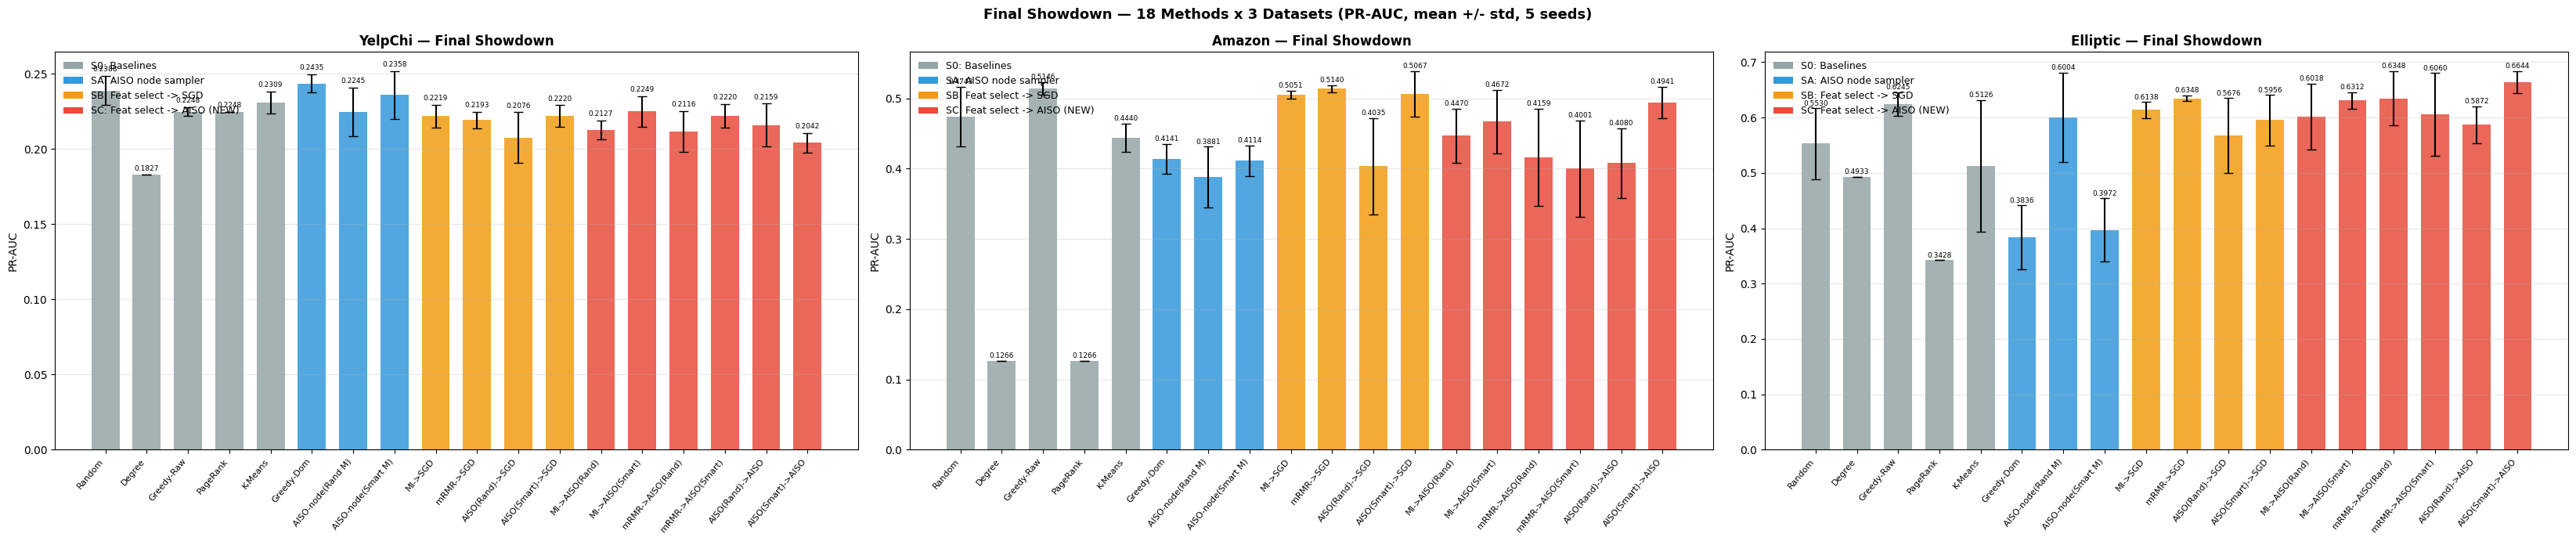

Saved: final_showdown.png


In [10]:
SEC_COLORS = {'S0': '#95a5a6', 'SA': '#3498db', 'SB': '#f39c12', 'SC': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(33, 7))

datasets = [('YelpChi', yelp_s), ('Amazon', amzn_s), ('Elliptic', elliptic_s)]
for ax, (dname, summary) in zip(axes, datasets):
    ms    = [m for m in METHOD_ORDER if m in summary]
    means = [summary[m]['mean'] for m in ms]
    stds  = [summary[m]['std']  for m in ms]
    cols  = [SEC_COLORS[SECTION.get(m, 'S0')] for m in ms]

    x    = np.arange(len(ms))
    ax.bar(x, means, yerr=stds, capsize=4, color=cols, alpha=0.85, width=0.68)
    ax.set_xticks(x)
    ax.set_xticklabels(ms, rotation=50, ha='right', fontsize=8)
    ax.set_ylabel('PR-AUC')
    ax.set_title('%s — Final Showdown' % dname, fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for xi, (mv, sv) in enumerate(zip(means, stds)):
        ax.text(xi, mv + sv + 0.002, '%.4f' % mv, ha='center', va='bottom', fontsize=6.5)

    legend_elements = [
        Patch(facecolor=SEC_COLORS['S0'], label='S0: Baselines'),
        Patch(facecolor=SEC_COLORS['SA'], label='SA: AISO node sampler'),
        Patch(facecolor=SEC_COLORS['SB'], label='SB: Feat select -> SGD'),
        Patch(facecolor=SEC_COLORS['SC'], label='SC: Feat select -> AISO (NEW)'),
    ]
    ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc='upper left')

plt.suptitle('Final Showdown — 18 Methods x 3 Datasets (PR-AUC, mean +/- std, 5 seeds)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(BASE / 'final_showdown.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: final_showdown.png')